In [ ]:
# =============================================================================
# This cell must be executed first: it sets up the Python path, imports all
# required libraries, configures the global Matplotlib style, and defines the
# helper functions used throughout the notebook.
# =============================================================================

from pathlib import Path
import sys

# ---------------------------------------------------------------------------
# Standard library imports
# ---------------------------------------------------------------------------
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import ipywidgets as widgets

# Optional: enable interactive Matplotlib backend in Jupyter
# %matplotlib widget

# ---------------------------------------------------------------------------
# Custom library imports (fail-soft with informative error messages)
# ---------------------------------------------------------------------------
try:
    import PyPump as pp          # Pumping-scheme reconstruction library
except Exception as e:
    print(f"[error] Could not import PyPump: {e}")

try:
    import myPy_functions as my  # Project-specific utility functions
except Exception as e:
    print(f"[error] Could not import myPy_functions: {e}")

# ---------------------------------------------------------------------------
# Global Matplotlib style
# ---------------------------------------------------------------------------
def apply_plot_style():
    """Apply a consistent publication-quality style to all Matplotlib figures."""
    mpl.rcParams.update({
        "axes.formatter.useoffset": False,       # Disable offset notation on axes
        "figure.constrained_layout.use": True,   # Automatic tight layout
        "axes.labelsize": 30,
        "font.size": 30,
        "legend.fontsize": 30,
        "legend.frameon": False,
        "font.weight": "normal",
        "font.family": "serif",
        # Uncomment to pin a specific serif font stack across platforms:
        # "font.serif": ["CMU Serif", "Computer Modern", "Times New Roman", "DejaVu Serif"],
        "mathtext.fontset": "cm",                # Computer Modern math font
    })

apply_plot_style()

# ---------------------------------------------------------------------------
# PyPump_g_from_S – recover pump amplitudes from a target scattering matrix
# ---------------------------------------------------------------------------
def PyPump_g_from_S(Saa, K, Id):
    """
    Recover the pumping scheme (complex amplitudes and frequencies) that
    reproduces a given scattering matrix Saa.

    Parameters
    ----------
    Saa : ndarray, shape (2*Nmodes, 2*Nmodes)
        Target scattering matrix in the (a, a†) basis.
    K   : ndarray, shape (2*Nmodes, 2*Nmodes)
        Coupling-rate diagonal matrix  (K = sqrt(gamma_ext) * I).
    Id  : ndarray, shape (2*Nmodes, 2*Nmodes)
        Identity matrix of the same size.

    Returns
    -------
    gp_k   : ndarray, complex
        Concatenated pump amplitudes [conversion pumps | squeezing pumps].
    omega_k : ndarray, float
        Corresponding pump frequencies [rad/s].
    """
    Nmodes = Saa.shape[0] // 2

    # Step 1: Reconstruct the interaction matrix M from S via input-output theory
    M = pp.M_reconstructed_from_S(Saa, K, Id)

    # Step 2: Decompose M into pump frequency components using PyPump
    (k_arr, k_arr_conv,
     magnitudes_Gamma_plus, phases_Gamma_plus,
     magnitudes_Gamma_minus, phases_Gamma_minus,
     magnitudes_G_plus, phases_G_plus,
     magnitudes_G_minus, phases_G_minus) = pp.compute_pumping_scheme_Fabio(Nmodes, 24, M, 1e-15)

    # Step 3: Assemble complex pump amplitudes for conversion and squeezing tones
    gp_k_fc  = magnitudes_G_plus     * np.exp(1j * phases_G_plus)    # frequency-conversion pumps
    gp_k_sq  = magnitudes_Gamma_plus * np.exp(1j * phases_Gamma_plus) # squeezing pumps

    # Step 4: Compute the corresponding pump frequencies
    omega_k_fc = k_arr_conv * Delta           # conversion-pump frequencies
    omega_k_sq = 2 * omega0 + k_arr * Delta  # squeezing-pump frequencies (two-photon)

    # Concatenate conversion and squeezing contributions
    gp_k    = np.concatenate([gp_k_fc,    gp_k_sq])
    omega_k = np.concatenate([omega_k_fc, omega_k_sq])

    return gp_k, omega_k


# ---------------------------------------------------------------------------
# assemble_M – build the system interaction matrix from pump coefficients
# ---------------------------------------------------------------------------
def assemble_M(g, gamma,
               G_plus_set, G_minus_set,
               Gamma_plus_set, Gamma_minus_set):
    """
    Assemble the off-diagonal part of the interaction matrix M as:

        M = Σ_k [ g_k G_k^+ + g_k* G_k^- + γ_k Γ_k^+ + γ_k* Γ_k^- ]

    where:
      - g_k  : complex conversion-pump amplitudes  (length N_m - 1)
      - γ_k  : complex squeezing-pump amplitudes   (length 2*N_m - 1)
      - G_k^± : mode-coupling matrices for frequency conversion
      - Γ_k^± : mode-coupling matrices for squeezing/two-mode squeezing

    Parameters
    ----------
    g, gamma           : array-like, complex
        Conversion and squeezing pump coefficient vectors.
    G_plus_set, G_minus_set         : list of ndarray
        Coupling matrices for conversion (positive / negative frequency).
    Gamma_plus_set, Gamma_minus_set : list of ndarray
        Coupling matrices for squeezing (positive / negative frequency).

    Returns
    -------
    M : ndarray, complex
        Assembled interaction matrix (off-diagonal part only; add D separately).
    """
    # Initialise M with zeros (same shape as the coupling matrices)
    M = np.zeros_like(G_plus_set[0], dtype=complex)

    # Add contribution from each conversion pump tone g_k (k = 1, …, N_m - 1)
    for idx, gk in enumerate(g, start=1):
        M += gk               * G_plus_set[idx - 1]
        M += np.conjugate(gk) * G_minus_set[idx - 1]

    # Add contribution from each squeezing pump tone γ_k (k = -(N_m-1), …, N_m-1)
    N_m = len(gamma) // 2 + 1
    for offset, gamma_k in enumerate(gamma):
        M += gamma_k               * Gamma_plus_set[offset]
        M += np.conjugate(gamma_k) * Gamma_minus_set[offset]

    return M


# ---------------------------------------------------------------------------
# build_coeff_vectors – convert a human-readable pump list into coefficient arrays
# ---------------------------------------------------------------------------
def build_coeff_vectors(pumps, N_m, g1_value):
    """
    Convert a list of pump definitions into the coefficient arrays used by assemble_M.

    Each pump is defined as a tuple:
        (k, amp_rel, phase, is_squeezing)
    where:
      - k         : integer mode index
                      conversion → k in [1, N_m-1]
                      squeezing  → k in [-(N_m-1), N_m-1]
      - amp_rel   : amplitude relative to the base coupling strength g1_value
      - phase     : pump phase in radians
      - is_squeezing : True for squeezing pump, False for conversion pump

    Parameters
    ----------
    pumps    : list of tuples
    N_m      : int – number of cavity modes
    g1_value : float – reference coupling strength

    Returns
    -------
    g     : ndarray, complex, shape (N_m - 1,)
    gamma : ndarray, complex, shape (2*N_m - 1,)
    """
    g     = np.zeros(N_m - 1,     dtype=complex)
    gamma = np.zeros(2 * N_m - 1, dtype=complex)

    for k, amp_rel, phase, is_sq in pumps:
        coeff = amp_rel * g1_value * np.exp(1j * phase) / 2
        if not is_sq:
            # Conversion pump: valid index range [1, N_m - 1]
            if 1 <= k <= N_m - 1:
                g[k - 1] = coeff
            else:
                raise ValueError(f"Conversion pump index k={k} out of range [1..{N_m - 1}]")
        else:
            # Squeezing pump: valid index range [-(N_m-1), N_m-1]
            idx = k + (N_m - 1)
            if 0 <= idx < 2 * N_m - 1:
                gamma[idx] = coeff
            else:
                raise ValueError(f"Squeezing pump index k={k} out of range [-{N_m-1}..{N_m-1}]")

    return g, gamma


# ---------------------------------------------------------------------------
# build_D_from_allmodes – construct the diagonal (free-evolution) part of M
# ---------------------------------------------------------------------------
def build_D_from_allmodes(allmodes_freq, omega0, gamma):
    """
    Build the diagonal matrix D of shape (2*Nmodes, 2*Nmodes) representing
    the free-evolution and decay terms in the rotating frame:

        D[2i,   2i  ] = -ω_{-k} - ω_0 + i γ/2   (negative-frequency component)
        D[2i+1, 2i+1] = -ω_{+k} + ω_0 + i γ/2   (positive-frequency component)

    The input `allmodes_freq` alternates negative/positive frequency pairs:
        [ω_{-n}, ω_{+n}, ω_{-(n-1)}, ω_{+(n-1)}, ..., ω_{-1}, ω_{+1}]

    Parameters
    ----------
    allmodes_freq : ndarray, shape (2*Nmodes,)
        Alternating negative/positive mode frequencies.
    omega0 : float  – central resonance angular frequency [rad/s].
    gamma  : float  – total field decay rate [rad/s].

    Returns
    -------
    D : ndarray, complex, shape (2*Nmodes, 2*Nmodes)
    """
    nm2 = allmodes_freq.size          # = 2 * Nmodes
    D   = np.zeros((nm2, nm2), dtype=complex)
    for i in range(0, nm2, 2):
        omega_minus_k = allmodes_freq[i]
        omega_plus_k  = allmodes_freq[i + 1]
        D[i,   i]   = -omega_minus_k - omega0 + 1j * gamma / 2
        D[i+1, i+1] = -omega_plus_k  + omega0 + 1j * gamma / 2
    return D


# ---------------------------------------------------------------------------
# Basis-change helpers: (a, a†) ↔ (x, p) quadrature bases
# ---------------------------------------------------------------------------
def to_xp(S_a, U):
    """Transform scattering matrix from (a, a†) to (x, p) quadrature basis."""
    return U.conj().T @ S_a @ U

def to_aa(S_xp, U):
    """Transform scattering matrix from (x, p) quadrature to (a, a†) basis."""
    return U @ S_xp @ U.conj().T


In [ ]:
# =============================================================================
# Two data files are loaded:
#   1. Sexp_abs_dB_13_best.npz  – contains the experimentally measured
#      scattering matrix (in dB), together with the pump amplitudes and
#      frequencies recovered from the inverse problem.
#   2. S_tar_dB_13_best.npz     – contains the target (designed) scattering
#      matrix in dB that the optimisation aimed to reproduce.
#
# NOTE: update the file paths below if the data files are stored elsewhere.
# =============================================================================

# Path to the experimental data archive
file_path  = "Sexp_abs_dB_13_best.npz"
# Path to the target scattering matrix archive
file_path2 = "S_tar_dB_13_best.npz"

# Load both archives (allow_pickle=True for compatibility with object arrays)
data  = np.load(file_path,  allow_pickle=True)
data2 = np.load(file_path2, allow_pickle=True)

# Print the variable names contained in each archive for verification
print("Variables in the experimental data file:")
print(data.files)
print("Variables in the target data file:")
print(data2.files)


Variables in the experimental data file:
['Sexp_abs_dB', 'gp_back', 'omega_back']
Variables in the target data file:
['S_tar_dB']


In [ ]:
# =============================================================================
# Print the shape and dtype of every array in both archives to verify that
# the data was loaded correctly before proceeding with the analysis.
# =============================================================================

print("Arrays in the experimental data file:")
for key in data.files:
    arr = data[key]
    print(f"  {key}: shape={arr.shape}, dtype={arr.dtype}")

print("\nArrays in the target data file:")
for key2 in data2.files:
    arr2 = data2[key2]
    print(f"  {key2}: shape={arr2.shape}, dtype={arr2.dtype}")


Arrays in the experimental data file:
  Sexp_abs_dB: shape=(13, 13), dtype=float64
  gp_back: shape=(37,), dtype=complex128
  omega_back: shape=(37,), dtype=float64

Arrays in the target data file:
  S_tar_dB: shape=(13, 13), dtype=float64


# Uploading the experimental data $S_{exp}$

In [ ]:
# =============================================================================
# Sexp_abs_dB : measured |S| matrix in dB (shape: Nmodes × Nmodes)
# gp_target   : complex pump amplitudes recovered from the inverse problem
#               (shape: N_pumps; first N-1 are conversion, rest are squeezing)
# omega_target: corresponding pump frequencies [rad/s]
# S_tar_dB    : designed target |S| matrix in dB (shape: Nmodes × Nmodes)
# =============================================================================

# Experimental scattering matrix (absolute value, normalised to dB)
Sexp_abs_dB  = data['Sexp_abs_dB']

# Pump amplitudes and frequencies from the back-projected (inverse) problem
gp_target    = data['gp_back']
omega_target = data['omega_back']

# Target (designed) scattering matrix in dB
S_tar_dB     = data2['S_tar_dB']


# Creating the target Scattering matrix $S_t$

In [ ]:
# =============================================================================
# Define all physical constants and simulation parameters, build the
# input-output coupling matrix K and the basis-change unitary U, then
# compute the target scattering matrix Saa_target in the (a, a†) basis.
# =============================================================================

# ---------------------------------------------------------------------------
# Resonance and frequency parameters
# ---------------------------------------------------------------------------
f0      = 4.2                        # Central resonance frequency [GHz]
omega0  = 2 * np.pi * f0             # Central angular frequency    [rad·GHz]
Delta_f = 0.1e-3                     # Mode spacing                 [GHz]
Delta   = 2 * np.pi * Delta_f        # Mode spacing in angular frequency [rad·GHz]

# ---------------------------------------------------------------------------
# Loss and coupling rates
# ---------------------------------------------------------------------------
gamma_int    = 0.0                            # Internal (intrinsic) loss rate [GHz]
gamma_ext    = 2 * np.pi * 100e6 / 1e9       # External (coupling) decay rate [GHz]
g1_value     = 24                            # Reference pump coupling strength [a.u.]
gamma_over_g = 10.0                          # Ratio γ/g (dissipation-to-coupling)

# Derived decay rates
gamma_r    = g1_value * gamma_over_g         # Reference total decay rate
gamma0_ext = gamma_ext * gamma_r             # Scaled external decay rate
gamma      = gamma_int + gamma0_ext          # Total field decay rate [rad·GHz]

# ---------------------------------------------------------------------------
# System size
# ---------------------------------------------------------------------------
Nmodes, _ = Sexp_abs_dB.shape   # Number of cavity modes (inferred from data)

# ---------------------------------------------------------------------------
# Input-output coupling matrix K and identity matrix
# ---------------------------------------------------------------------------
# K = sqrt(gamma_ext) * I_{2N}  (factor 2N because each mode has 2 quadratures)
K  = np.identity(2 * Nmodes) * np.sqrt(gamma0_ext)
Id = np.eye(2 * Nmodes, dtype=complex)   # Identity matrix for input-output formula

# ---------------------------------------------------------------------------
# Basis-change matrices: (a, a†) ↔ (x, p)
# ---------------------------------------------------------------------------
# The single-mode unitary U_2x2 satisfies:  vec(a) = U · vec(x)
# Its inverse Udag satisfies:               vec(x) = Udag · vec(a)
U_2by2    = (1 / np.sqrt(2)) * np.array([[1,  1j],
                                          [1, -1j]])    # a  = U x
Udag_2by2 = (1 / np.sqrt(2)) * np.array([[ 1,  1 ],
                                          [-1j, 1j]])   # x  = Udag a

# Extend to the full N-mode system via Kronecker product
U    = np.kron(np.eye(Nmodes, dtype=complex), U_2by2)
Udag = np.linalg.inv(U)

# ---------------------------------------------------------------------------
# Target scattering matrix
# ---------------------------------------------------------------------------
# Compute the full (2N × 2N) scattering matrix Saa_target in the (a, a†) basis
# using the pump amplitudes and frequencies recovered from the inverse problem.
Saa_target, _ = my.compute_bigS_from_g(Nmodes, gp_target, omega_target, omega0, Delta)

# Convert to the (x, p) quadrature basis (result should be real-valued)
Sxp_target = np.real(Udag @ Saa_target @ U)


# Reconstructing the Scattering matrix $S_{rec}$

In [ ]:
# =============================================================================
# Given the target scattering matrix Saa_target, reconstruct the pump
# amplitudes (gp_rec) and frequencies (omega_rec) that generate it.
# This is the core inverse step: M is first recovered from S via
# input-output theory, then decomposed into pump tones by PyPump.
# =============================================================================

# Recover pump amplitudes and frequencies from the target scattering matrix
gp_rec, omega_rec = PyPump_g_from_S(Saa_target, K, Id)

# Re-synthesise the scattering matrix from the recovered pumping scheme to
# verify the reconstruction quality (Saa_rec should closely match Saa_target)
Saa_rec, _ = my.compute_bigS_from_g(Nmodes, gp_rec, omega_rec, omega0, Delta)


# Computing the numerical pump-off Scattering matrix for reference $S_{OFF}$

In [ ]:
# =============================================================================
# With all pump amplitudes set to zero, the system reduces to N uncoupled
# resonators.  The resulting diagonal scattering matrix S0 is used as the
# normalisation reference when converting |S| to dB.
# =============================================================================

# Generate the frequency vectors for the full mode set
# modes_freq    : single-sided mode frequencies
# modes_labels  : string labels for each mode
# allmodes_freq : alternating [ω_{-k}, ω_{+k}] pairs, needed for matrix D
modes_freq, modes_labels, allmodes_freq = my.generate_freq_vectors(Nmodes, omega0, Delta)

# ---------------------------------------------------------------------------
# Define the pump configuration (empty → pump-off reference)
# ---------------------------------------------------------------------------
# Each pump is specified as: (mode_index k, relative_amplitude, phase [rad], is_squeezing)
squeezing_pumps  = []   # No squeezing pumps for the reference calculation
conversion_pumps = []   # No conversion pumps for the reference calculation
pumps = squeezing_pumps + conversion_pumps

# ---------------------------------------------------------------------------
# Build coefficient vectors, coupling matrices, and the interaction matrix M
# ---------------------------------------------------------------------------
# 1) Coefficient vectors g (conversion) and gam (squeezing) — both zero here
g, gam = build_coeff_vectors(pumps, Nmodes, g1_value)

# 2) Pre-computed basis matrices for constructing M from pump coefficients
G_plus_set,     G_minus_set     = pp.generate_G_set(Nmodes)     # conversion
Gamma_plus_set, Gamma_minus_set = pp.generate_Gamma_set(Nmodes) # squeezing

# 3) Off-diagonal pump contribution to M (zero for pump-off)
M = assemble_M(g, gam,
               G_plus_set,   G_minus_set,
               Gamma_plus_set, Gamma_minus_set)

# 4) Diagonal free-evolution + decay part of M
D = build_D_from_allmodes(allmodes_freq, omega0, gamma)

# 5) Full interaction matrix (off-diagonal pumps + diagonal free-evolution)
M = M + D
M_inv = np.linalg.inv(M)

# ---------------------------------------------------------------------------
# Compute S0 via input-output theory:  S = i K M^{-1} K - I
# ---------------------------------------------------------------------------
S0       = 1j * K @ M_inv @ K - Id

# Extract the physical (Nmodes × Nmodes) block from the full (2N × 2N) matrix
S0_small = my.extract_small_S(S0)

# Average diagonal magnitude used as the dB normalisation reference
S0_num_ref = np.mean(np.abs(np.diag(S0_small)))


# Preparing the normalized matrices

In [ ]:
# =============================================================================
# All matrices are normalised by the pump-off reference S0_num_ref so that
# the bare-cavity transmission corresponds to 0 dB.  A small regularisation
# constant eps prevents log(0) when entries are numerically zero.
# =============================================================================

eps = 1e-12   # Small regularisation constant to avoid log(0)

# --- Target scattering matrix (from the inverse problem) ---
# Extract the physical Nmodes × Nmodes block from the full 2N × 2N matrix
Saa_target_small = my.extract_small_S(Saa_target)
# Normalise by the pump-off reference and convert to dB
Saa_target_dB    = my.dB(np.abs(Saa_target_small) / S0_num_ref + eps)

# --- Reconstructed scattering matrix (from back-projected pumps) ---
Saa_rec_small = my.extract_small_S(Saa_rec)
Saa_rec_dB    = my.dB(np.abs(Saa_rec_small) / S0_num_ref + eps)

# --- Experimental scattering matrix (loaded directly from file, already in dB) ---
Saa_exp_dB = Sexp_abs_dB


In [ ]:
# =============================================================================
# stem_once wraps Matplotlib's ax.stem() to produce uniformly styled stem
# plots (consistent marker size, line width, and color).  It also hides the
# baseline and applies a single color to both the markers and the stems.
# =============================================================================

def stem_once(ax, x, y, ms=7, lw=1.5, color=None, label=None):
    """
    Draw a stem plot on `ax` with consistent styling.

    Parameters
    ----------
    ax    : matplotlib.axes.Axes  – target axes
    x, y  : array-like            – stem positions and heights
    ms    : float                 – marker size (default 7)
    lw    : float                 – stem line width (default 1.5)
    color : color spec or None    – uniform color for markers and stems
    label : str or None           – legend label

    Returns
    -------
    m : Line2D – the marker Line2D object (useful for legend handles)
    """
    # Draw the stem plot; suppress the baseline formatting (handled separately)
    m, stems, base = ax.stem(x, y, basefmt=" ", label=label)

    # Set marker size
    m.set_markersize(ms)

    # Set stem line width (API differs between Matplotlib versions)
    if hasattr(stems, "set_linewidth"):
        stems.set_linewidth(lw)
    else:
        try:
            for s in stems:
                s.set_linewidth(lw)
        except TypeError:
            pass

    # Apply uniform color to markers and stems (if specified)
    if color is not None:
        try:
            m.set_color(color)
        except Exception:
            pass
        try:
            m.set_markerfacecolor(color)
        except Exception:
            pass
        try:
            stems.set_color(color)
        except Exception:
            try:
                for s in stems:
                    s.set_color(color)
            except Exception:
                pass

    # Hide the baseline (aesthetics: the axhline at y=0 is drawn separately)
    if base is not None:
        try:
            base.set_visible(False)
        except Exception:
            pass

    return m


In [ ]:
# =============================================================================
# The recovered pump vector gp_rec is split into conversion (first N-1 entries)
# and squeezing (remaining 2N-1 entries) components.  Zero-padding is added on
# both sides so that the two groups appear in separate regions of the x-axis
# when plotted side by side.
# =============================================================================

deps  = 0.5   # Horizontal offset applied when overlaying multiple stem plots
scale = 1     # x-axis scale factor (increase to spread stems further apart)

# ---------------------------------------------------------------------------
# Split the recovered pump vector into conversion and squeezing components
# ---------------------------------------------------------------------------
gp_rec_conv = gp_rec[:Nmodes - 1]   # Conversion pump amplitudes  (length N-1)
gp_rec_sq   = gp_rec[Nmodes - 1:]   # Squeezing pump amplitudes   (length 2N-1)

# Zero-padding arrays of the same length as the conversion block
gp_empty = np.zeros(Nmodes - 1, dtype=complex)

# Padded concatenation: [zeros | conv pumps | zeros | squeezing pumps]
# This layout separates the two groups on the x-axis.
gp_pad = np.concatenate([gp_empty, gp_rec_conv, gp_empty, gp_rec_sq])

# ---------------------------------------------------------------------------
# Compute the x-axis index ranges for each pump group in the padded array
# ---------------------------------------------------------------------------
L = Nmodes - 1   # Length of the conversion-pump block

# Indices of the conversion-pump entries inside the padded array
idx_conv = np.arange(L, 2 * L)

# Indices of the squeezing-pump entries inside the padded array
idx_sq   = np.arange(3 * L, 3 * L + (2 * Nmodes - 1))

# Scaled x-coordinates for each group (for the stem plot horizontal axis)
x_conv = idx_conv * scale
x_sq   = idx_sq   * scale


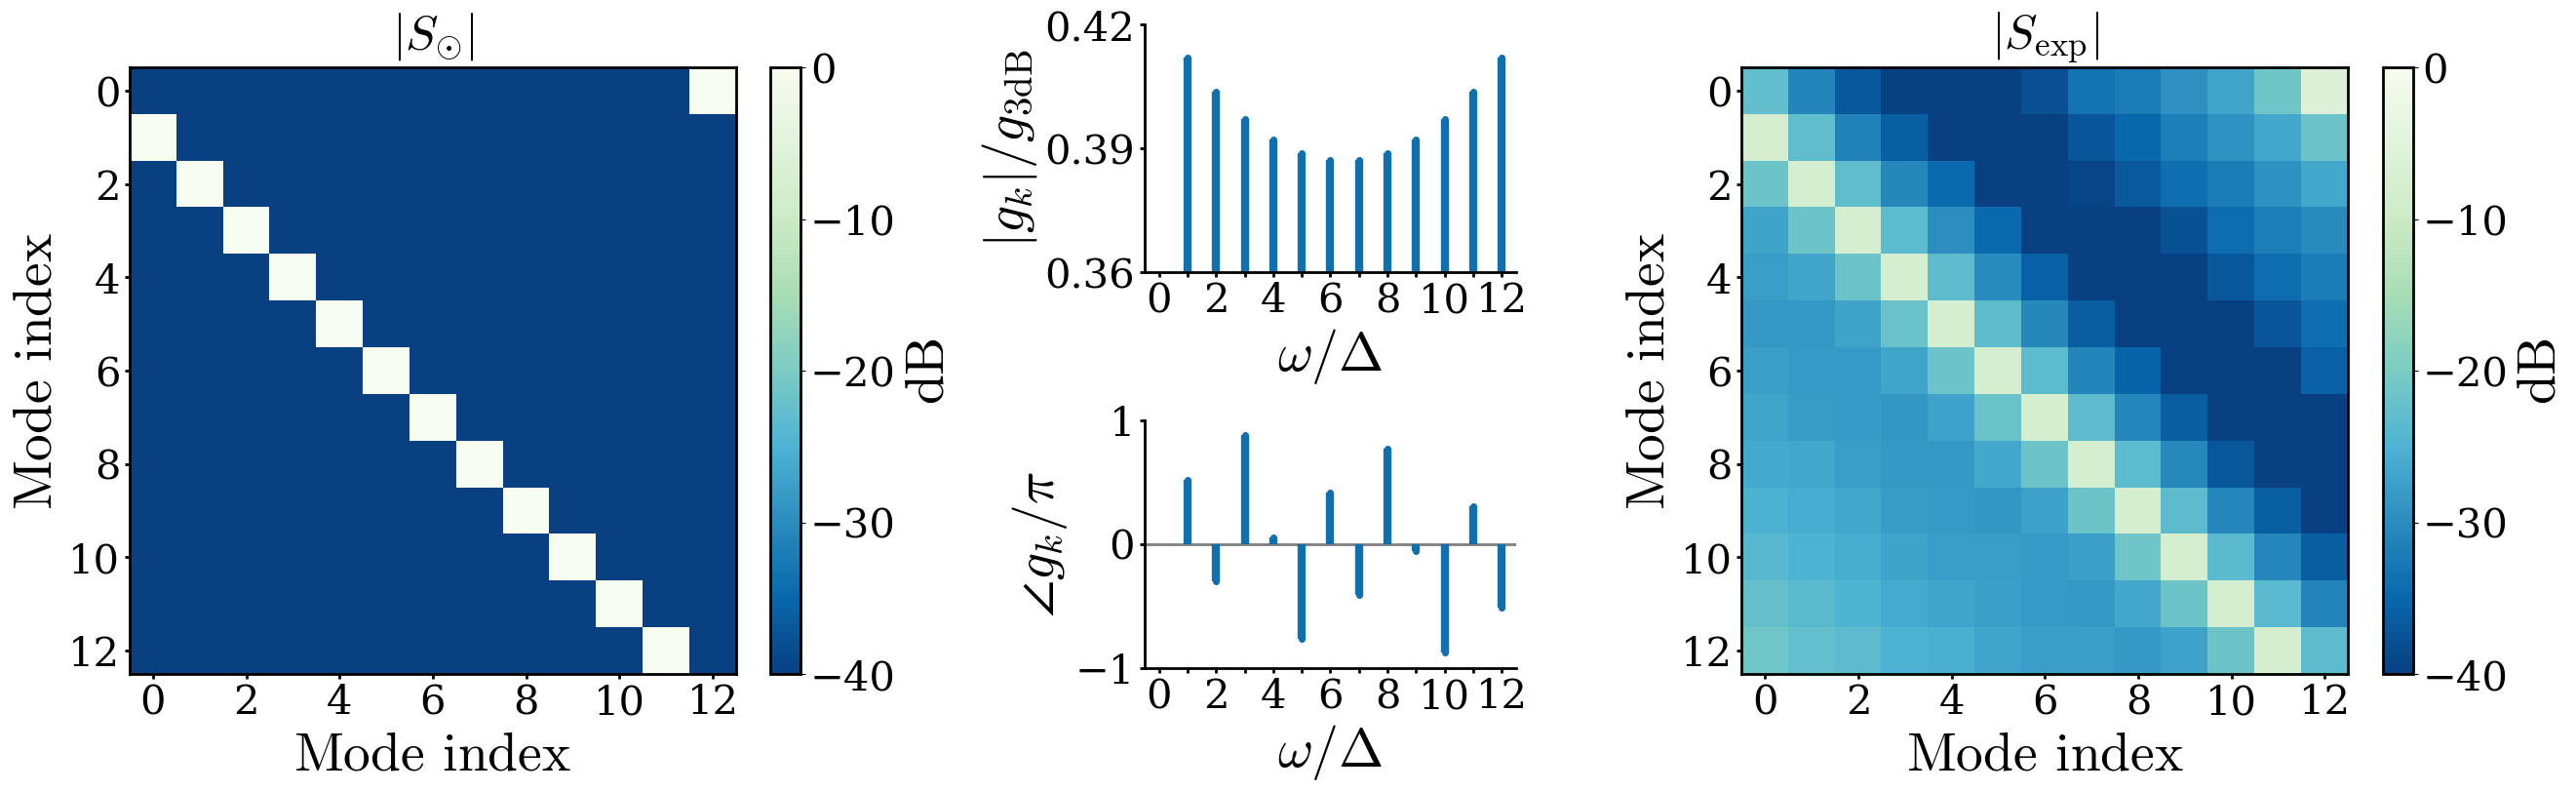

In [ ]:
# =============================================================================
# The figure has three panels arranged horizontally:
#   Left   (col 0): Heat-map of the target scattering matrix |S_⊙| [dB]
#   Centre (col 1): Stem plots of recovered pump magnitudes and phases
#   Right  (col 2): Heat-map of the experimental scattering matrix |S_exp| [dB]
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.lines import Line2D

# ---------------------------------------------------------------------------
# Shared colormap settings for the heat-map panels
# ---------------------------------------------------------------------------
col_map      = "GnBu_r"   # Colormap (reversed green-blue)
vmin, vmax   = -40, 0     # dB range displayed in the heat-maps

# Pixel centers for the mode-index tick marks (0 … Nmodes-1)
pixel_centers = np.arange(Nmodes)
tick_labels   = np.arange(Nmodes)

# Recompute scaled x-coordinates for the stem panels (consistent with Cell 14)
x_conv = idx_conv * scale
x_sq   = idx_sq   * scale

# ---------------------------------------------------------------------------
# Figure layout: 1 row × 3 columns with custom width ratios
# ---------------------------------------------------------------------------
fig   = plt.figure(figsize=(27, 8))
outer = gridspec.GridSpec(
    nrows=1, ncols=3, figure=fig,
    width_ratios=[1, 0.7, 1],   # Heat-map | stem plots | heat-map
    wspace=0.05                 # Minimal horizontal gap between panels
)

# ---------------------------------------------------------------------------
# Column 0 and 2: scattering matrix heat-maps
# ---------------------------------------------------------------------------
ax_im0 = fig.add_subplot(outer[0, 0])   # Left panel  – target S
ax_im1 = fig.add_subplot(outer[0, 2])   # Right panel – experimental S

# Plot the target scattering matrix
pl0 = ax_im0.imshow(S_tar_dB,   cmap=col_map, vmin=vmin, vmax=vmax, aspect='equal')
# Plot the experimental scattering matrix
pl1 = ax_im1.imshow(Saa_exp_dB, cmap=col_map, vmin=vmin, vmax=vmax, aspect='equal')

# Panel titles
ax_im0.set_title(r"$|S_{\odot}|$",        y=1.02)
ax_im1.set_title(r"$|S_{\text{exp}}|$",   y=1.02)

# Axis labels and tick marks (show only even mode indices to avoid crowding)
for a in (ax_im0, ax_im1):
    a.set_xlabel(r"$\text{Mode index}$", fontsize=40)
    a.set_ylabel(r"$\text{Mode index}$", fontsize=40)
    even_idx = np.arange(0, Nmodes, 2)            # Even mode indices only
    a.set_xticks(even_idx)
    a.set_yticks(even_idx)
    a.set_xticklabels([str(i) for i in even_idx])
    a.set_yticklabels([str(i) for i in even_idx])

# ---------------------------------------------------------------------------
# Colorbars for the heat-map panels
# ---------------------------------------------------------------------------
# Colorbar for the target matrix (left panel)
cbar0 = fig.colorbar(pl0, ax=ax_im0, location='right', fraction=0.046, pad=0.04)
cbar0.set_ticks(np.arange(vmin, vmax + 1, 10))
cbar0.set_label(r"$\text{dB}$", fontsize=40)
for spine in cbar0.ax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(2)

# Colorbar for the experimental matrix (right panel)
cbar1 = fig.colorbar(pl1, ax=ax_im1, location='right', fraction=0.046, pad=0.04)
cbar1.set_ticks(np.arange(vmin, vmax + 1, 10))
cbar1.set_label(r"$\text{dB}$", fontsize=40)
for spine in cbar1.ax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(2)

# ---------------------------------------------------------------------------
# Colormap-derived colors for the stem plots
# ---------------------------------------------------------------------------
cmap         = plt.get_cmap(col_map)
bottom_color = cmap(0.15)   # Color used for all stem markers and lines
mid_color    = cmap(0.5)    # Reserved for future use (e.g., squeezing pumps)

# ---------------------------------------------------------------------------
# Column 1: two vertically stacked stem plots (magnitude and phase)
# ---------------------------------------------------------------------------
right    = outer[0, 1].subgridspec(nrows=2, ncols=1, hspace=0.05)
ax_mag   = fig.add_subplot(right[0, 0])                        # Top: magnitudes
ax_phase = fig.add_subplot(right[1, 0], sharex=ax_mag)         # Bottom: phases (shared x)

# Dummy Line2D handles (reserved for legend entries if needed)
handle_target = Line2D([0], [0], color=bottom_color, lw=6,  marker='o', linestyle='None')
handle_exp    = Line2D([0], [0], color=bottom_color, lw=10, marker='o', linestyle='None')

# ---------------------------------------------------------------------------
# Normalise pump amplitudes by the 3-dB coupling strength
# ---------------------------------------------------------------------------
g_3dB  = 0.21   # 3-dB coupling strength (set to the experimental value)
best_g = 1      # Overall scaling factor (1 = no additional rescaling)

amps     = np.abs(gp_rec_conv).astype(float)
amps_sum = amps.sum()
# Normalise so that the amplitudes sum to 1, then scale by best_g / g_3dB
amps = amps / amps_sum if amps_sum != 0 else amps
amps = best_g * amps / g_3dB

# ---------------------------------------------------------------------------
# Top stem panel: pump magnitudes |g_k| / g_{3dB}
# ---------------------------------------------------------------------------
ax_mag.axhline(0, color='gray', linestyle='-', linewidth=2)   # Baseline at zero
stem_once(ax_mag, x_conv, amps, ms=4, lw=6, color=bottom_color)
# To also show squeezing pumps, uncomment:
# stem_once(ax_mag, x_sq, np.abs(gp_pad[idx_sq]), ms=7, lw=2, color=bottom_color)

ax_mag.set_ylabel(r'$|g_k|/g_{3\text{dB}}$', fontsize=40)
ax_mag.set_ylim(0.36, 0.42)
ax_mag.set_yticks([0.36, 0.39, 0.42])

# ---------------------------------------------------------------------------
# Shared x-axis tick marks (conversion pump indices, even labels only)
# ---------------------------------------------------------------------------
all_k     = np.unique(x_conv)
extra     = all_k.min() - 1                                    # Extra tick before the first pump
all_k_ext = np.concatenate([[extra], all_k])

# Raw labels: "0" for the extra tick, then "1", "2", … for each pump tone
labels_raw  = ["0"] + [str(i + 1) for i in range(len(all_k))]
# Show only even-numbered labels (replace odd labels with a blank space)
labels_even = [lab if int(lab) % 2 == 0 else " " for lab in labels_raw]

ax_mag.set_xticks(all_k_ext)
ax_mag.set_xticklabels(labels_even)
ax_mag.set_xlabel(r'$\omega/\Delta$', fontsize=40)
ax_mag.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
ax_mag.set_xlim(all_k_ext.min() - 0.5, all_k_ext.max() + 0.5)  # Slight padding

# ---------------------------------------------------------------------------
# Bottom stem panel: pump phases ∠g_k / π
# ---------------------------------------------------------------------------
ax_phase.axhline(0, color='gray', linestyle='-', linewidth=2)  # Baseline at zero
stem_once(ax_phase, x_conv, np.angle(gp_rec_conv) / np.pi, ms=4, lw=6, color=bottom_color)
# To also show squeezing pump phases, uncomment:
# stem_once(ax_phase, x_sq, np.angle(gp_pad[idx_sq]) / np.pi, ms=7, lw=2, color=bottom_color)

ax_phase.set_ylabel(r'$\angle g_k/\pi$', fontsize=40)
ax_phase.set_ylim(-1, 1)
ax_phase.set_yticks([-1, 0, 1])

ax_phase.set_xticks(all_k_ext)
ax_phase.set_xticklabels(labels_even)
ax_phase.set_xlabel(r'$\omega/\Delta$', fontsize=40)
ax_phase.set_xlim(all_k_ext.min() - 0.5, all_k_ext.max() + 0.5)

# ---------------------------------------------------------------------------
# Uniform spine and tick styling for all panels
# ---------------------------------------------------------------------------
for ax in (ax_im0, ax_im1, ax_mag, ax_phase):
    for s in ax.spines.values():
        s.set_linewidth(2)
    ax.tick_params(axis='both', which='both', width=2)

# Remove top and right spines from the stem panels (cleaner appearance)
for ax in (ax_mag, ax_phase):
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

# ---------------------------------------------------------------------------
# Optional: save the figure (uncomment and set the desired output path)
# ---------------------------------------------------------------------------
# fig.savefig("circulator_best.svg", bbox_inches="tight", transparent=True)

plt.show()
